# Exploratory Data Analysis

This notebook analyses the gathered AIS (Automatic Identification System) data before and after cleaning. Both the raw unfiltered dataset and the cleaned Type 1/2/3 position report dataset are compared visually and statistically, so the effect of the cleaning process becomes clear.

The notebook is structured around three deliverables:

1. Histograms of all 7 AIS features, compared side by side
2. Geographical maps of recorded coordinates, at world scale and zoomed into the Norwegian coast
3. A summary statistics table exported to Markdown

Histograms are used instead of line charts because the goal is to show value distributions across the dataset, not trends over time. They clearly expose how many records fall within each value range and make out-of-range values immediately visible.

Throughout this notebook, red (`#C0392B`) is used for raw/unfiltered data and blue (`#2E86C1`) for cleaned/processed data.

## Imports

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib

# Switch to inline rendering so all plots appear directly in the notebook output
%matplotlib inline

## Load datasets

Two CSV files are loaded:

| File | Description |
|------|-------------|
| `ais_type123_clean.csv` | Cleaned dataset, only Type 1/2/3 position reports with invalid field values removed |
| `ais_decoded_20260305_2124.csv` | Full decoded dataset, all message types, no filtering applied |

The cleaned file is the direct output of the previous cleaning script (`02_clean.py`).

In [3]:
df = pd.read_csv("../data/processed/ais_type123_clean.csv")
print(f"Loaded {len(df)} clean records")

df_unfiltered = pd.read_csv("../data/processed/ais_decoded_20260305_2124.csv")
print(f"Loaded {len(df_unfiltered)} unfiltered records")

Loaded 648253 clean records
Loaded 1161491 unfiltered records


## Feature Histograms

The 7 features below are the core fields of AIS Type 1/2/3 (Class A position report) messages:

| Field | Description | Valid range |
|-------|-------------|-------------|
| `lat` | Latitude | -90 to 90 |
| `lon` | Longitude | -180 to 180 |
| `sog` | Speed Over Ground (knots) | 0 to 102.2 |
| `cog` | Course Over Ground (degrees) | 0 to 360 |
| `heading` | True Heading (degrees) | 0 to 359, where 511 means not available |
| `rot` | Rate of Turn (degrees/min) | -127 to 127, where -128 means not available |
| `nav_status` | Navigational Status | 0 to 15 (integer code) |

In the unfiltered data, values like `cog > 360` or `rot = 512` show up, which are impossible according to the AIS standard (ITU-R M.1371). The cleaning step specifically targets these anomalies. The histograms below show the before and after.

In [4]:
def plot_histograms(df, title, filename, color):
    """
    Plot a 3x3 grid of histograms for the 7 core AIS position-report features.

    Parameters
    ----------
    df       : pd.DataFrame  - dataset to visualise
    title    : str           - super-title displayed above all subplots
    filename : str           - output path for the saved PNG file
    color    : str           - hex colour for the histogram bars
    """
    features = ['lat', 'lon', 'sog', 'cog', 'heading', 'rot', 'nav_status']
    plt.figure(figsize=(20, 12))

    for i, feature in enumerate(features):
        plt.subplot(3, 3, i + 1)
        plt.hist(df[feature], bins=30, alpha=0.7, color=color)
        plt.title(f"{feature} distribution")
        plt.xlabel(feature)
        plt.ylabel("Frequency")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(filename)
    print(f"Saved: {filename}")
    plt.show()

Saved: ../data/processed/eda_histograms_unfiltered.png


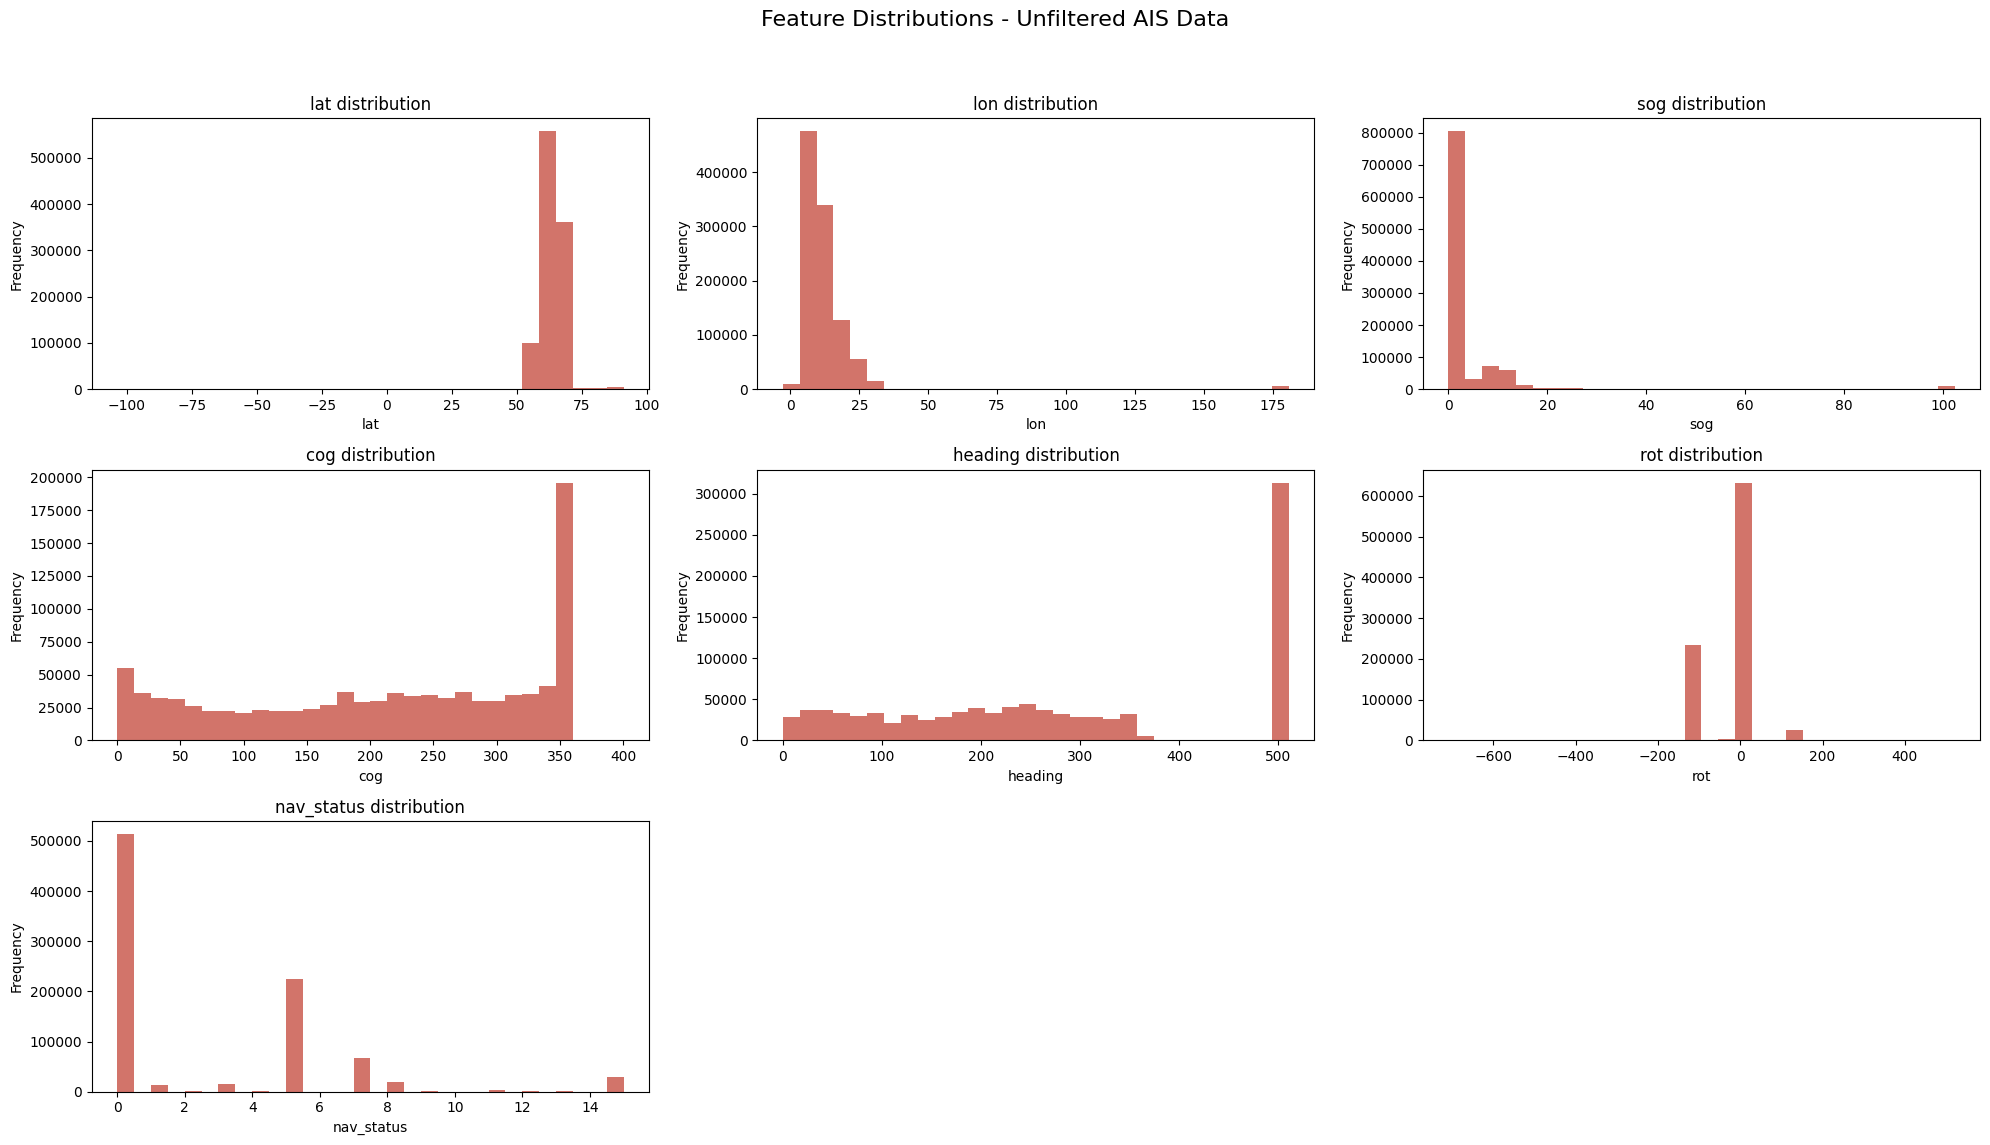

In [5]:
# Unfiltered data
plot_histograms(
    df_unfiltered,
    "Feature Distributions - Unfiltered AIS Data",
    "../data/processed/eda_histograms_unfiltered.png",
    color='#C0392B'
)

Saved: ../data/processed/eda_histograms.png


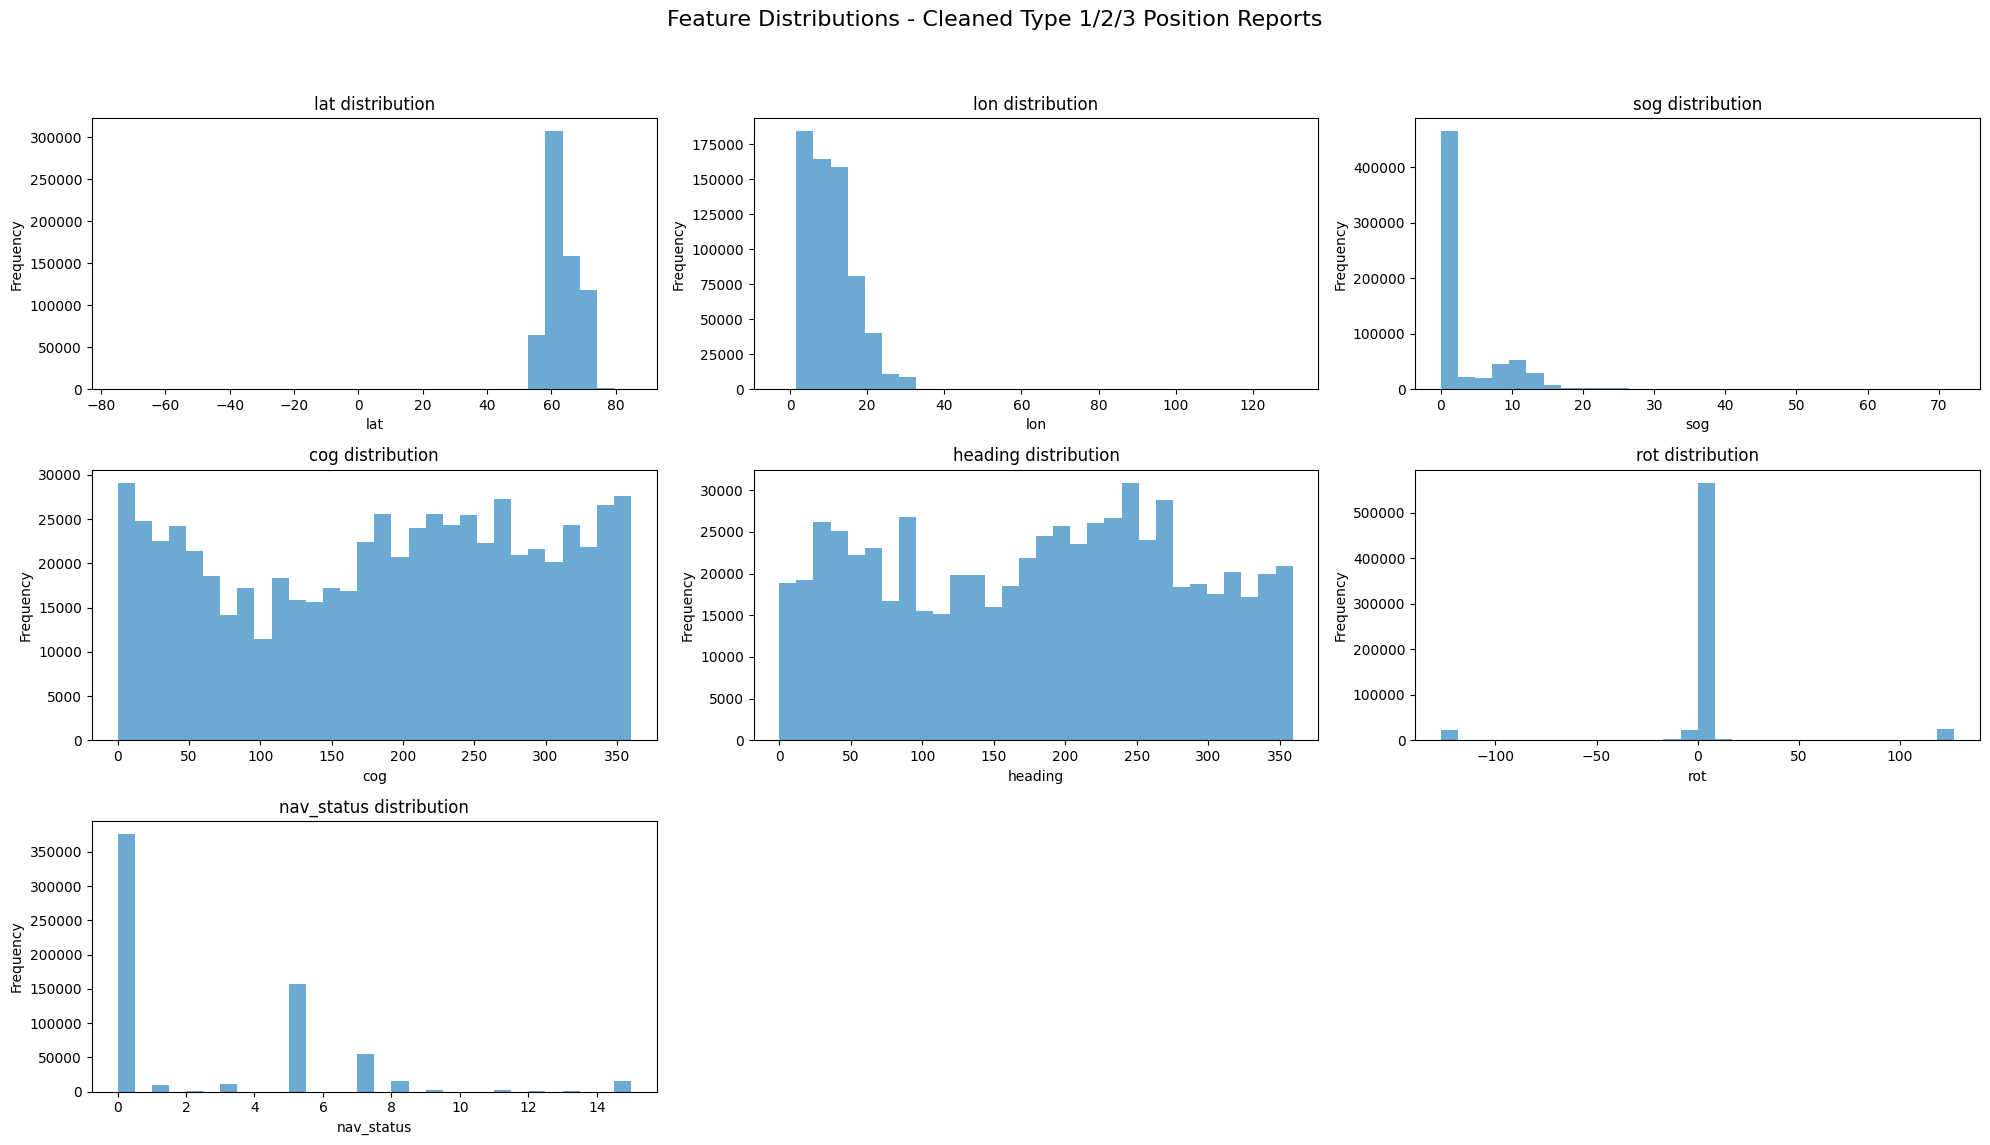

In [6]:
# Cleaned data
plot_histograms(
    df,
    "Feature Distributions - Cleaned Type 1/2/3 Position Reports",
    "../data/processed/eda_histograms.png",
    color='#2E86C1'
)

The x-axis ranges in the unfiltered histograms are noticeably wider and exceed valid AIS field boundaries. Several of them also show significant spikes at sentinel values such as `heading = 511` or `rot = 512`, which indicate missing or corrupt readings in the raw stream. After cleaning, the distributions are more compact and physically meaningful, with records concentrated in realistic value ranges. The total record count drops accordingly.

## Geographical Maps

AIS data is inherently spatial, so plotting the `lat`/`lon` coordinates onto a map is a good sanity check: are vessels appearing where they are physically expected to be?

The base world map comes from the Natural Earth 110m cultural boundaries dataset, loaded via GeoPandas. Each AIS record is plotted as a small semi-transparent dot to handle the high density of points without saturating the image.

Two comparisons are produced: a full world view and a zoomed-in view of the Norwegian coast (lon: -5 to 35, lat: 54 to 75), which is the expected area of the data collection.

In [7]:
# Load world boundary shapefile, used as backdrop for the coordinate scatter plots
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

### World view

Saved: eda_map.png


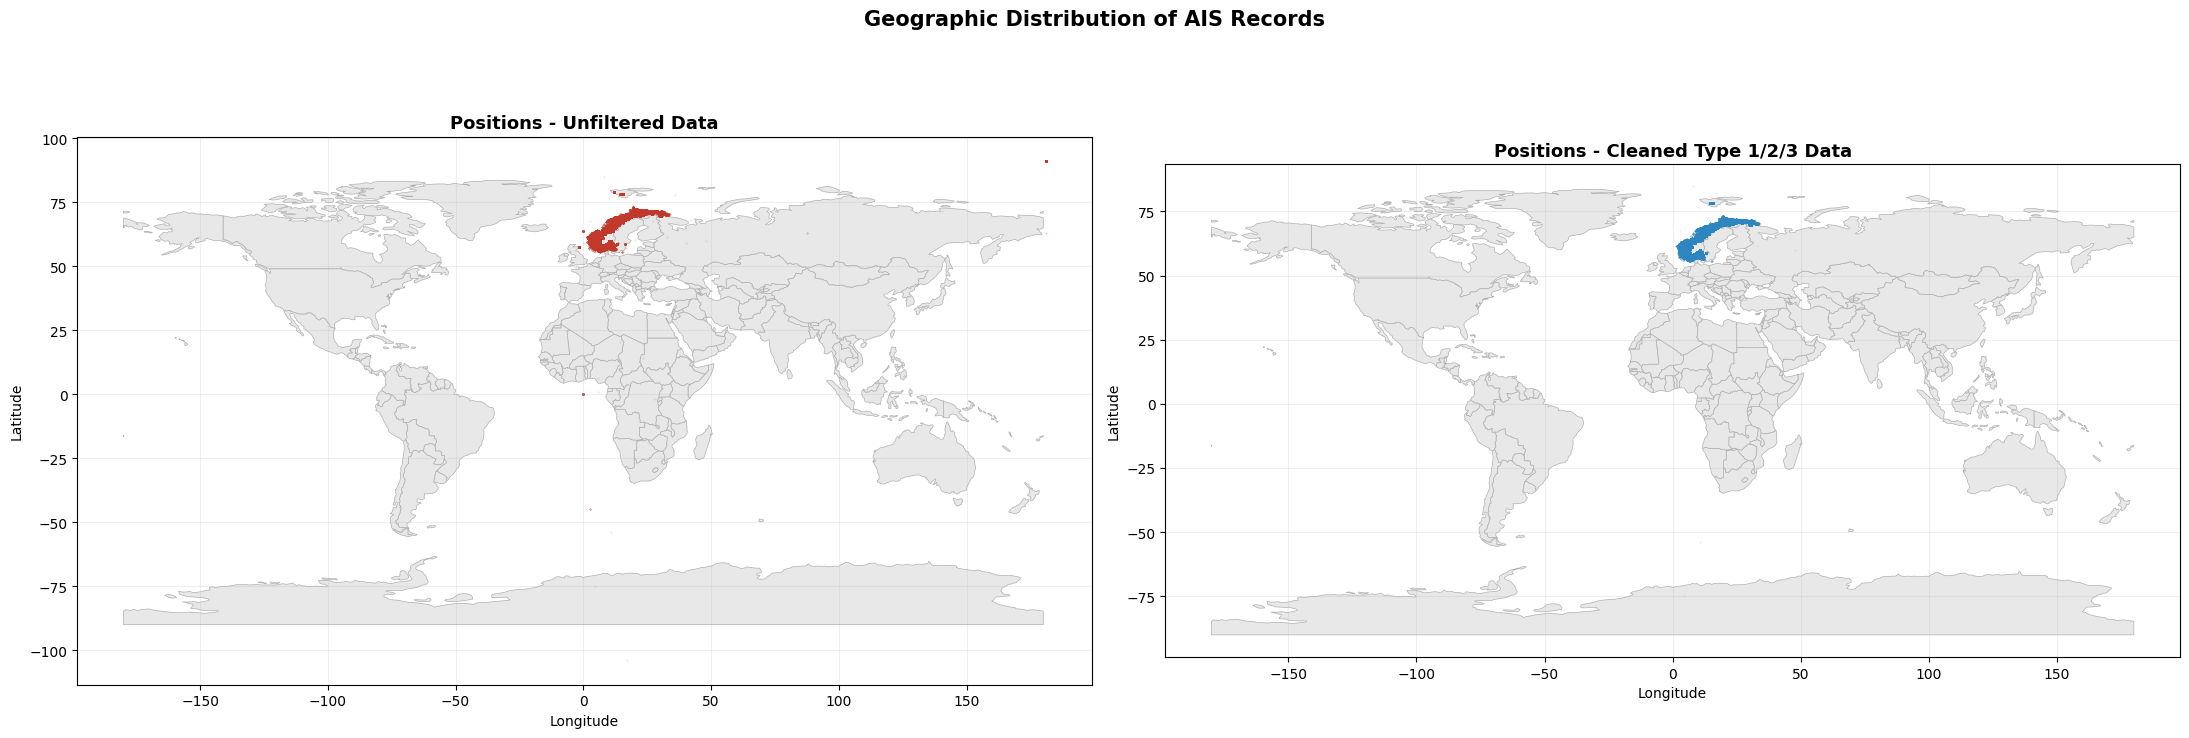

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Left panel: unfiltered
world.plot(ax=axes[0], color='#E8E8E8', edgecolor='#B0B0B0', linewidth=0.5)
axes[0].scatter(df_unfiltered['lon'], df_unfiltered['lat'], s=0.05, alpha=0.3, color='#C0392B')
axes[0].set_title('Positions - Unfiltered Data', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].grid(True, alpha=0.2)

# Right panel: cleaned
world.plot(ax=axes[1], color='#E8E8E8', edgecolor='#B0B0B0', linewidth=0.5)
axes[1].scatter(df['lon'], df['lat'], s=0.05, alpha=0.3, color='#2E86C1')
axes[1].set_title('Positions - Cleaned Type 1/2/3 Data', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].grid(True, alpha=0.2)

plt.suptitle('Geographic Distribution of AIS Records', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/processed/eda_map.png", dpi=150)
print("Saved: eda_map.png")
plt.show()

### Norwegian coast (zoomed)

Saved: eda_map_zoomed.png


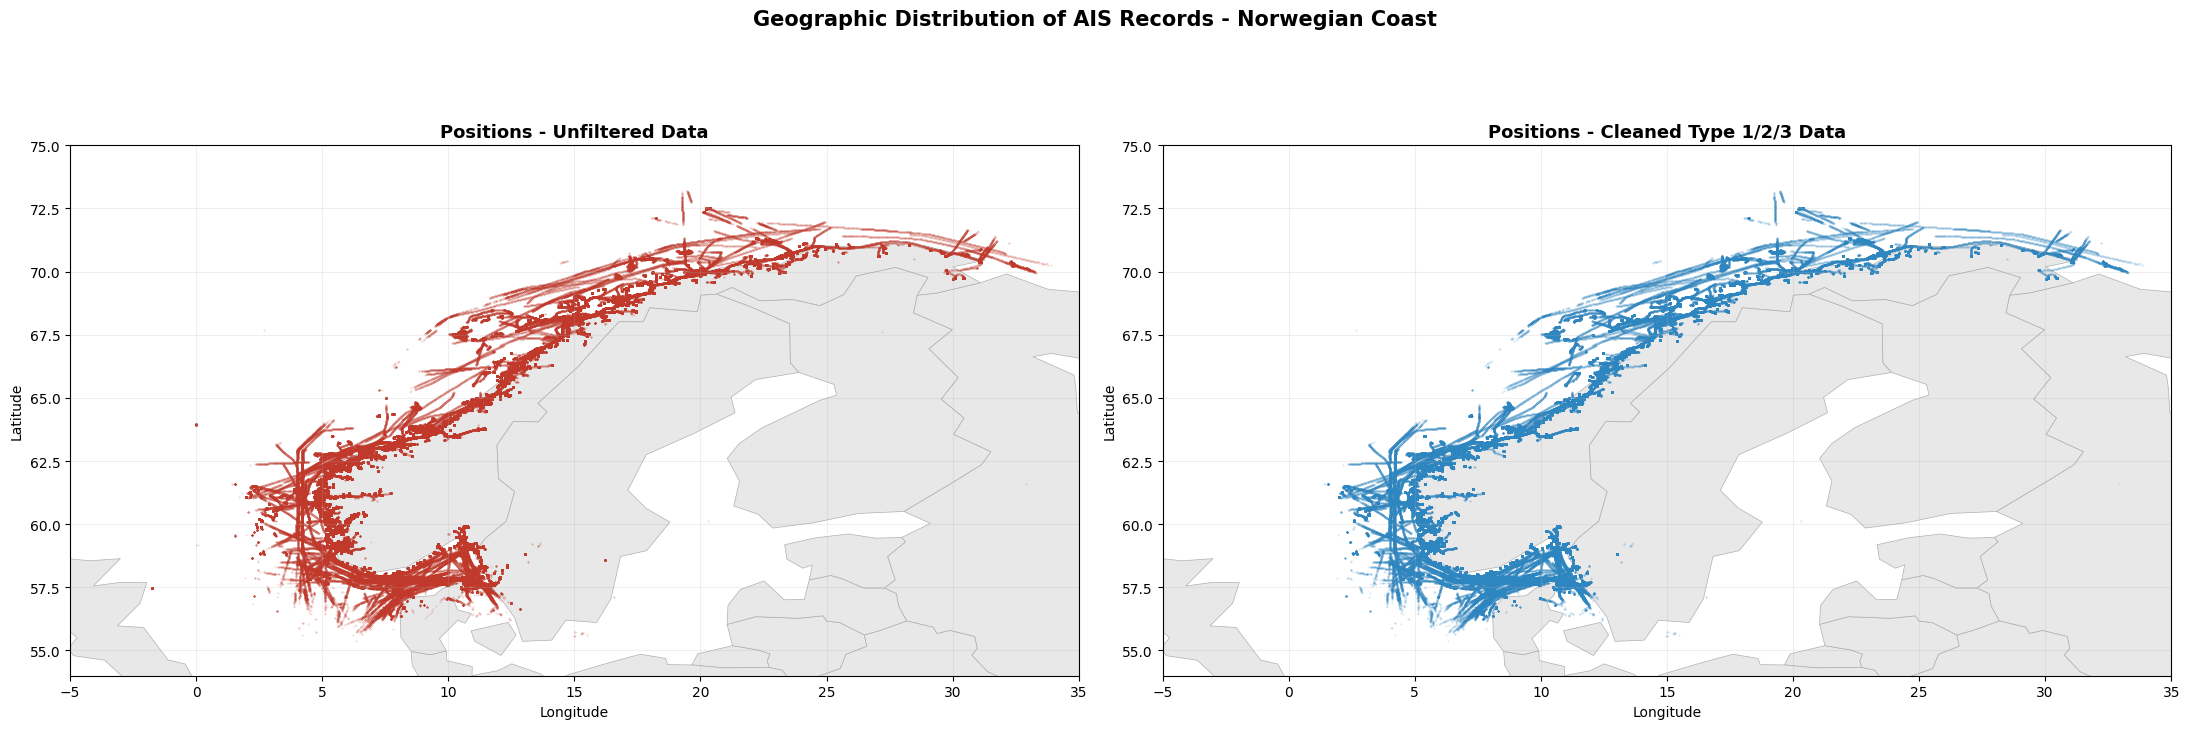

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Left panel: unfiltered, zoomed to Norwegian coast
world.plot(ax=axes[0], color='#E8E8E8', edgecolor='#B0B0B0', linewidth=0.5)
axes[0].scatter(df_unfiltered['lon'], df_unfiltered['lat'], s=0.1, alpha=0.3, color='#C0392B')
axes[0].set_title('Positions - Unfiltered Data', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_xlim(-5, 35)
axes[0].set_ylim(54, 75)
axes[0].grid(True, alpha=0.2)

# Right panel: cleaned, zoomed to Norwegian coast
world.plot(ax=axes[1], color='#E8E8E8', edgecolor='#B0B0B0', linewidth=0.5)
axes[1].scatter(df['lon'], df['lat'], s=0.1, alpha=0.3, color='#2E86C1')
axes[1].set_title('Positions - Cleaned Type 1/2/3 Data', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_xlim(-5, 35)
axes[1].set_ylim(54, 75)
axes[1].grid(True, alpha=0.2)

plt.suptitle('Geographic Distribution of AIS Records - Norwegian Coast', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/processed/eda_map_zoomed.png", dpi=150)
print("Saved: eda_map_zoomed.png")
plt.show()

The world view shows a clear difference. With enough data points, offsets outside the expected area become visible: scattered records west of Africa, in central Russia and in the far northwest. These are geographically impossible positions that the cleaning step removes.

The zoomed Norwegian coast map shows less of a dramatic difference. Most of the filtered records were not removed because of invalid geographic coordinates specifically, and the ones that were tend to be located outside this region anyway. With over 648,000 cleaned records and 1,161,000 unfiltered records, individual outliers also become very small at this scale. Both maps are still included in the project, but should be read with that context in mind.

## Summary Statistics

The cell below generates a Markdown file (`eda_summary.md`) with two components. First, descriptive statistics (count, mean, std, min, quartiles, max) for all 7 features, computed separately for the unfiltered Type 1/2/3 subset and the cleaned dataset using `pandas.DataFrame.describe()`. Second, a key observations table with derived metrics that quickly summarise the cleaning impact and the composition of the cleaned dataset.

To make the comparison fair, the unfiltered dataset is first filtered to Type 1/2/3 messages only, since the cleaned dataset already contains only those.

In [11]:
features = ['lat', 'lon', 'sog', 'cog', 'heading', 'rot', 'nav_status']

# Isolate Type 1/2/3 records from the unfiltered dataset for a fair comparison
df_unfiltered_pos = df_unfiltered[df_unfiltered["msg_type"].isin([1, 2, 3])]

with open("../data/processed/eda_summary.md", "w") as f:
    def write(line=""):
        f.write(line + "\n")

    write("# EDA Summary\n")

    write(f"## Unfiltered Type 1/2/3 Data ({len(df_unfiltered_pos)} records, {df_unfiltered_pos['mmsi'].nunique()} vessels)\n")
    write(df_unfiltered_pos[features].describe().round(4).to_markdown())

    write(f"\n## Cleaned Type 1/2/3 Data ({len(df)} records, {df['mmsi'].nunique()} vessels)\n")
    write(df[features].describe().round(4).to_markdown())

    write(f"\n## Key Observations\n")
    write(f"| Metric | Value |")
    write(f"|--------|-------|")
    write(f"| Records removed by cleaning | {len(df_unfiltered_pos) - len(df)} ({(len(df_unfiltered_pos) - len(df)) / len(df_unfiltered_pos) * 100:.1f}%) |")
    write(f"| Vessels removed by cleaning | {df_unfiltered_pos['mmsi'].nunique() - df['mmsi'].nunique()} ({(df_unfiltered_pos['mmsi'].nunique() - df['mmsi'].nunique()) / df_unfiltered_pos['mmsi'].nunique() * 100:.1f}%) |")
    write(f"| Stationary vessels (SOG=0) | {(df['sog'] == 0).sum()} ({(df['sog'] == 0).sum() / len(df) * 100:.1f}%) |")
    write(f"| Nav status 0 (under way) | {(df['nav_status'] == 0).sum()} ({(df['nav_status'] == 0).sum() / len(df) * 100:.1f}%) |")
    write(f"| Nav status 5 (moored) | {(df['nav_status'] == 5).sum()} ({(df['nav_status'] == 5).sum() / len(df) * 100:.1f}%) |")
    write(f"| Nav status 15 (undefined) | {(df['nav_status'] == 15).sum()} ({(df['nav_status'] == 15).sum() / len(df) * 100:.1f}%) |")

print("Saved: eda_summary.md")

# print saved summary inline
with open("../data/processed/eda_summary.md", "r") as f:
    print(f.read())
    




Saved: eda_summary.md
# EDA Summary

## Unfiltered Type 1/2/3 Data (895512 records, 3718 vessels)

|       |         lat |         lon |         sog |        cog |    heading |         rot |   nav_status |
|:------|------------:|------------:|------------:|-----------:|-----------:|------------:|-------------:|
| count | 895512      | 895512      | 895512      | 895512     | 895512     | 895512      |  895512      |
| mean  |     63.8127 |     11.7957 |      3.1037 |    210.772 |    261.363 |    -29.9345 |       2.6359 |
| std   |      4.6954 |     13.6543 |     10.4905 |    118.385 |    167.621 |     62.0201 |       3.6395 |
| min   |   -103.743  |     -2.7926 |      0      |      0     |      0     |   -709      |       0      |
| 25%   |     59.91   |      5.8768 |      0      |    109.2   |    124     |   -127      |       0      |
| 50%   |     63.0517 |     10.0272 |      0      |    225.6   |    238     |      0      |       0      |
| 75%   |     67.7662 |     14.0216 |      0.

The summary table makes it easy to distinguish both datasets at a glance. Fields like `cog` going above 360 degrees or `rot` hitting 512 degrees per minute are clearly visible in the unfiltered statistics and absent in the cleaned ones. The key observations section adds context on how many records and vessels were removed and gives a quick breakdown of navigational status distribution in the cleaned data.